# MCIB. Interpolación (basado en PDI.Taller 2. Preprocesamiento de imágenes digitales)

Objetivos. Al terminar la práctica, el alumnado será capaz de :

*   Utilizar la funcionalidad de Python para la modificar imágenes.
*   Interpretar los resultados y parámetros usados en  escalamiento de intensidad y redimensionamiento de imágenes.
*   Analizará el efecto del "morphing" con diferentes interpolaciones.





In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Librerias necesarias

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as img
import numpy as np
from scipy.interpolate import CubicSpline  #Librería para interpolación spline cúbica
from scipy.interpolate import make_interp_spline   ##Librería para interpolación spline de orden ajustable (k): spline_2 = make_interp_spline(x, y, k=2)
import cv2  #Libreria de Computer Vision útil para el procesamiento de imágenes

## Lectura de archivo e información de la imagen

In [ ]:
I = img.imread('/content/drive/MyDrive/Docencia/PDI/Imagenes/IRM2.jpg')
print("Tamaño: ", I.shape)
print('Clase del objeto leido:', type(I))


Tamaño:  (256, 256)
Clase del objeto leido: <class 'numpy.ndarray'>


## Despliegue de la imagen

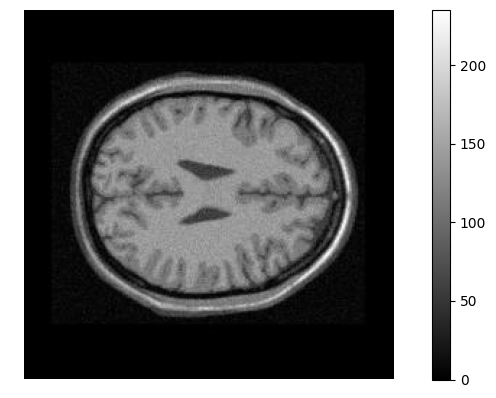

In [ ]:
plt.imshow(I, cmap='gray') #En grises
plt.axis('off')
plt.axis('equal')
plt.colorbar()
plt.show()


In [ ]:
Im=np.float32(I)      #Conversió de entero a flotante

## Escalamiento lineal de intensidades

In [ ]:
def escalamiento_lineal(I,minimo,maximo):
  I_min=np.min(I)
  I_max=np.max(I)
  G=np.zeros(I.shape)
  G=(((I-I_min)*(maximo-minimo))/(I_max-I_min))+minimo
  return G


Iescalada=escalamiento_lineal(Im,0,255)



-12.255325


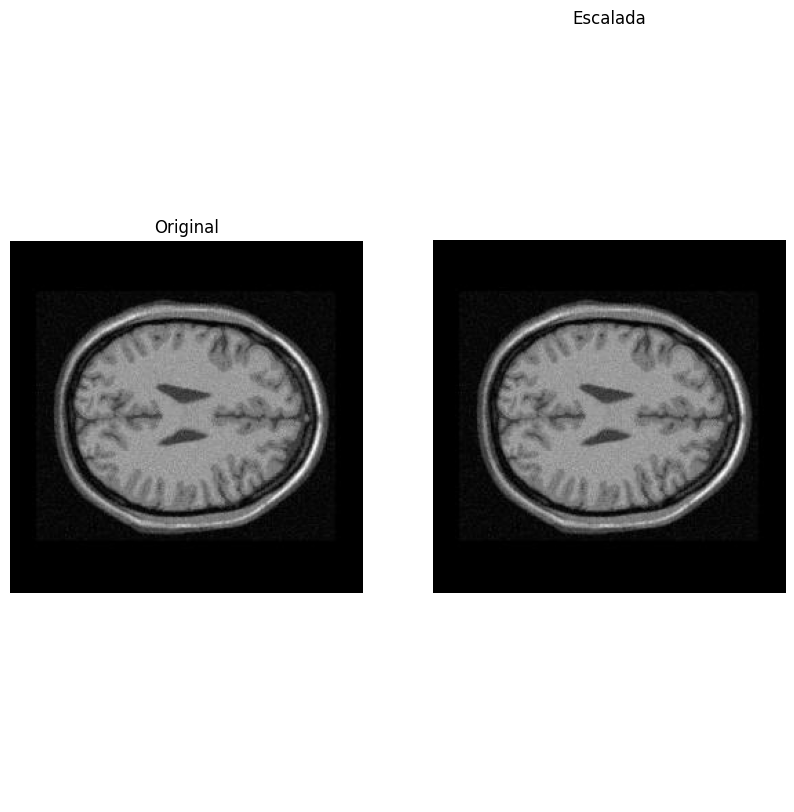

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 10))

axs[0].imshow(Im, cmap='gray')
axs[0].axis('off')
axs[0].set_title('Original')
plt.axis('equal')


axs[1].imshow(Iescalada, cmap='gray')
axs[1].axis('off')
axs[1].set_title('Escalada')
plt.axis('equal')

#plt.tight_layout()
plt.show()


### Transformaciones geométricas

Estas transformaciones que actúan sobre las coordenadas de la imagen (renglones y columnas) pueden ser sintetizadas como una matriz de transformación de la forma:

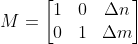

para un desplazamiento.

De manera similar para la escala y la rotación. La multiplicación sucesiva de estas matrices de transformación sobre la imagen generan la transformación final deseada.

#### Escalamiento de la imagen

In [ ]:
Sn=0.5
Sm=0.25
M = np.float32([[Sn,0,0],[0,Sm,0]])
Izoom= cv2.warpAffine(Im,M,Im.shape, cv2.INTER_NEAREST_EXACT)
print(Izoom.shape)

(256, 256)


In [ ]:
plt.imshow(Izoom, cmap='gray')
plt.axis('off')
plt.title('Zoom')
plt.axis('equal')
plt.colorbar()

#### Otra vía para el escalamiento de la imagen

In [ ]:
Izoom2= cv2.resize(Im,(50,100), interpolation=cv2.INTER_NEAREST)
Izoom3= cv2.resize(Im,(50,100), interpolation=cv2.INTER_CUBIC)

print(Izoom2.shape)


(100, 50)


In [ ]:
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(Izoom2, cmap='gray')
plt.axis('off')
plt.title('NN')
plt.axis('equal')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(Izoom3, cmap='gray')
plt.axis('off')
plt.title('Cubic')
plt.axis('equal')
plt.colorbar()

## Acondicionamiento de imagen

1. Escala los niveles de gris de las imágenes a un intervalo de [0,1]
2. Redimiensiona las imágenes a una altura o anchura máxima de 256 pixeles (escalamiento espacial proporcional). AMBAS IMÁGENES DEL MISMO TAMAÑO.
3. Selecciona una imagen como Io (original) y la otra será Id (destino).
4. Codifica la interpolación spline cúbica para llevar cada pixel desde la Io hasta el valor de la Id, al menos en diez pasos. Prueba N=10 y 50.
5. Calcula el error de la última imagen interpolada respecto a la Id.
6. Genera una animación mostrando la imagen interpolada en cada paso.